In [1]:
!apt-get install -y tesseract-ocr poppler-utils
!pip install pytesseract pdf2image opencv-python pandas pillow

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
The following NEW packages will be installed:
  poppler-utils
0 upgraded, 1 newly installed, 0 to remove and 42 not upgraded.
Need to get 186 kB of archives.
After this operation, 697 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 poppler-utils amd64 22.02.0-2ubuntu0.12 [186 kB]
Fetched 186 kB in 0s (1,302 kB/s)
Selecting previously unselected package poppler-utils.
(Reading database ... 122354 files and directories currently installed.)
Preparing to unpack .../poppler-utils_22.02.0-2ubuntu0.12_amd64.deb ...
Unpacking poppler-utils (22.02.0-2ubuntu0.12) ...
Setting up poppler-utils (22.02.0-2ubuntu0.12) ...
Processing triggers for man-db (2.10.2-1) ...


In [2]:
import pytesseract
from pdf2image import convert_from_path
import cv2
import pandas as pd

print("Tesseract version:", pytesseract.get_tesseract_version())
print("OpenCV version:", cv2.__version__)
print("All set.")

Tesseract version: 4.1.1
OpenCV version: 4.13.0
All set.


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os
os.makedirs('/content/drive/MyDrive/annual-report-ocr/data', exist_ok=True)
os.makedirs('/content/drive/MyDrive/annual-report-ocr/output', exist_ok=True)
print("Folders ready.")

Folders ready.


In [5]:
!wget -O /content/drive/MyDrive/annual-report-ocr/data/sample_scan.pdf "https://www.sec.gov/Archives/edgar/data/320193/0000912057-95-000938.txt"

--2026-05-06 08:29:35--  https://www.sec.gov/Archives/edgar/data/320193/0000912057-95-000938.txt
Resolving www.sec.gov (www.sec.gov)... 88.221.157.213, 2600:1409:3c00:b8b::17b2, 2600:1409:3c00:b86::17b2
Connecting to www.sec.gov (www.sec.gov)|88.221.157.213|:443... connected.
HTTP request sent, awaiting response... 403 Forbidden
2026-05-06 08:29:35 ERROR 403: Forbidden.



In [6]:
!wget -O /content/drive/MyDrive/annual-report-ocr/data/sample_scan.pdf "https://www.sec.gov/Archives/edgar/data/320193/0000912057-95-000938.txt"

--2026-05-06 08:29:35--  https://www.sec.gov/Archives/edgar/data/320193/0000912057-95-000938.txt
Resolving www.sec.gov (www.sec.gov)... 88.221.157.213, 2600:1409:3c00:b8b::17b2, 2600:1409:3c00:b86::17b2
Connecting to www.sec.gov (www.sec.gov)|88.221.157.213|:443... connected.
HTTP request sent, awaiting response... 403 Forbidden
2026-05-06 08:29:35 ERROR 403: Forbidden.



In [7]:
!wget --user-agent="Mozilla/5.0" \
  -O /content/drive/MyDrive/annual-report-ocr/data/cocacola_1975.pdf \
  "https://archive.org/download/cocacolacoannualreports/cocacola1975.pdf"

import os
path = '/content/drive/MyDrive/annual-report-ocr/data/cocacola_1975.pdf'
size_mb = os.path.getsize(path) / 1e6
print(f"Downloaded: {size_mb:.1f} MB")

--2026-05-06 08:29:36--  https://archive.org/download/cocacolacoannualreports/cocacola1975.pdf
Resolving archive.org (archive.org)... 207.241.224.2
Connecting to archive.org (archive.org)|207.241.224.2|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://dn790008.ca.archive.org/0/items/cocacolacoannualreports/cocacola1975.pdf [following]
--2026-05-06 08:29:36--  https://dn790008.ca.archive.org/0/items/cocacolacoannualreports/cocacola1975.pdf
Resolving dn790008.ca.archive.org (dn790008.ca.archive.org)... 184.105.203.175
Connecting to dn790008.ca.archive.org (dn790008.ca.archive.org)|184.105.203.175|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3235163 (3.1M) [application/pdf]
Saving to: ‘/content/drive/MyDrive/annual-report-ocr/data/cocacola_1975.pdf’

/content/drive/MyDr 100%[===================>]   3.08M  17.4MB/s    in 0.2s    

2026-05-06 08:29:37 (17.4 MB/s) - ‘/content/drive/MyDrive/annual-report-ocr/data/cocacola_1975.

In [8]:
from pdf2image import convert_from_path
import os

pdf_path = '/content/drive/MyDrive/annual-report-ocr/data/cocacola_1975.pdf'

# Get total page count without converting
from pdf2image.pdf2image import pdfinfo_from_path
info = pdfinfo_from_path(pdf_path)
print(f"Total pages: {info['Pages']}")
print(f"Page size: {info['Page size']}")

Total pages: 28
Page size: 474.24 x 686.88 pts


Image size: (1318, 1908) pixels
Mode: RGB


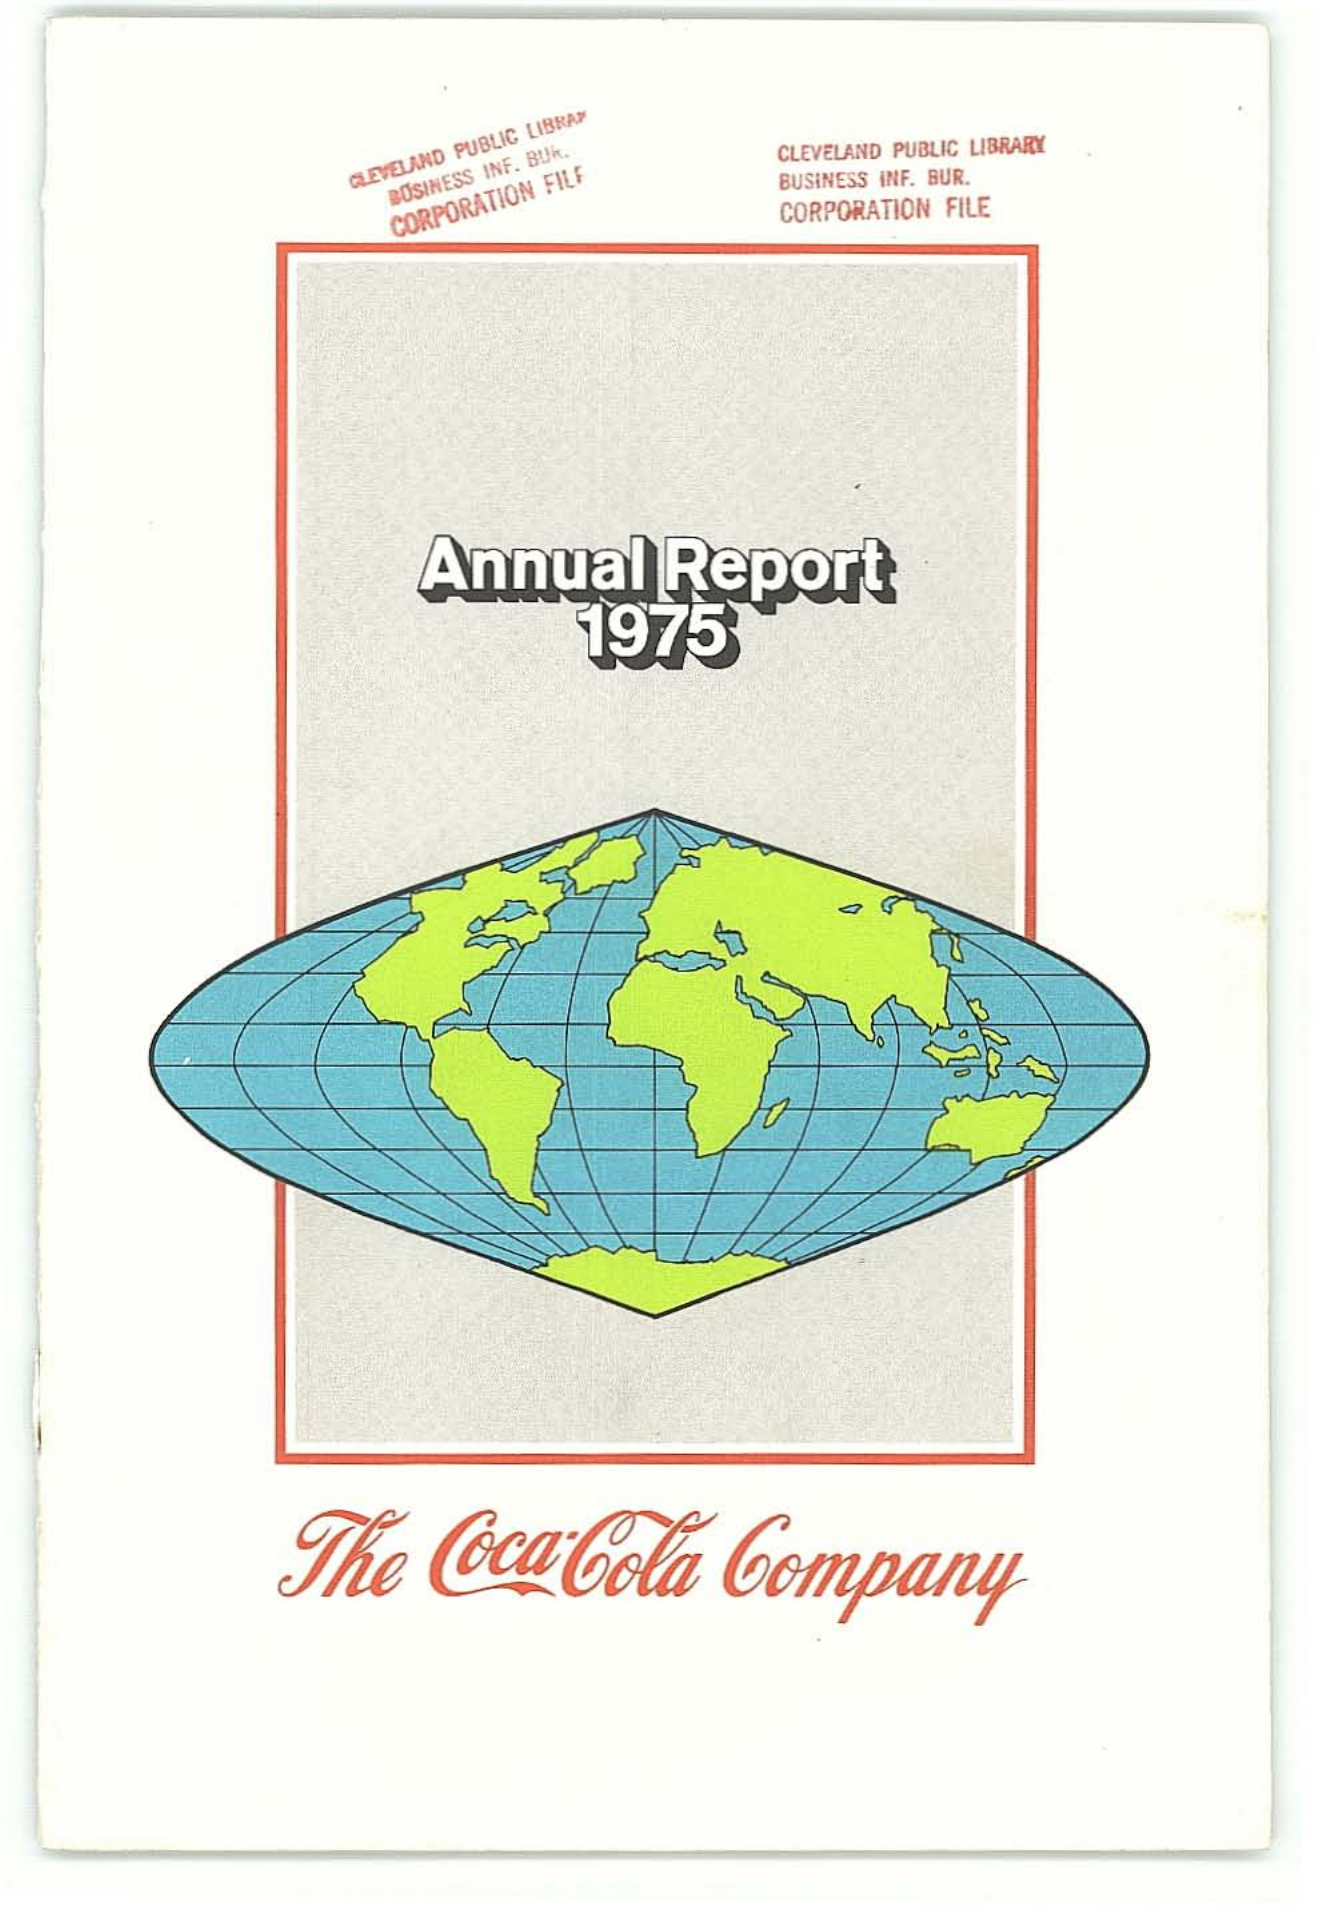

In [9]:
from pdf2image import convert_from_path
from PIL import Image

# Convert only page 1, at 200 DPI to keep memory low
pages = convert_from_path(pdf_path, dpi=200, first_page=1, last_page=1)
page1 = pages[0]

print(f"Image size: {page1.size} pixels")
print(f"Mode: {page1.mode}")

# Display it inline
page1

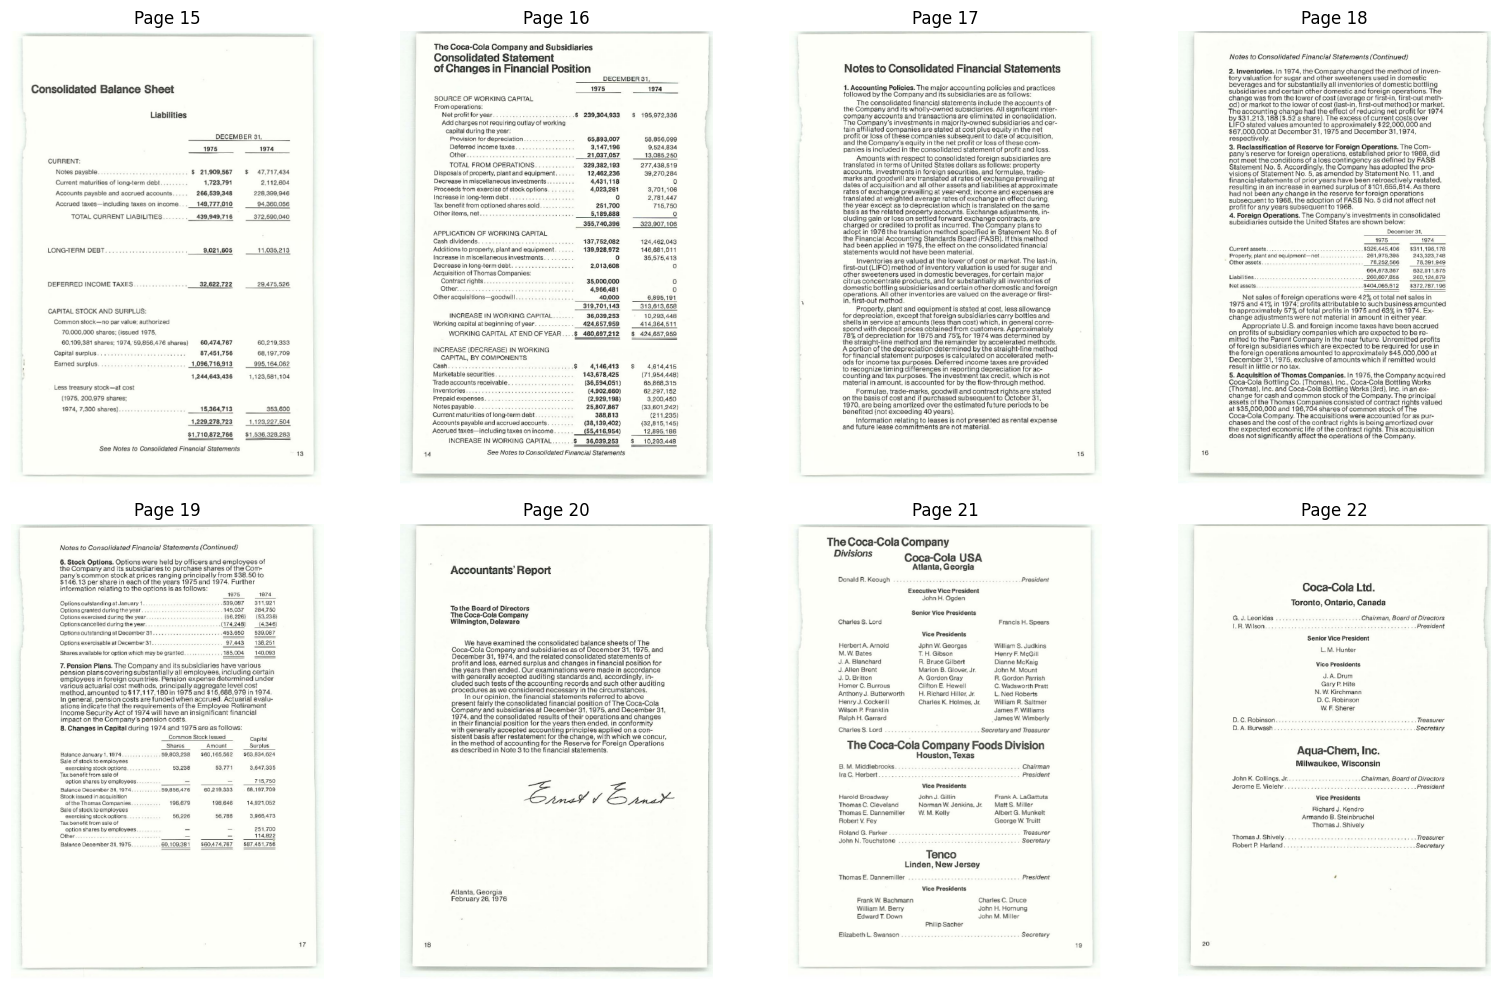

In [10]:
from pdf2image import convert_from_path
import matplotlib.pyplot as plt

pdf_path = '/content/drive/MyDrive/annual-report-ocr/data/cocacola_1975.pdf'

# Convert pages 15-22 at low DPI for fast preview
preview_pages = convert_from_path(pdf_path, dpi=80, first_page=15, last_page=22)

fig, axes = plt.subplots(2, 4, figsize=(16, 10))
for i, (page, ax) in enumerate(zip(preview_pages, axes.flat)):
    ax.imshow(page)
    ax.set_title(f'Page {15 + i}')
    ax.axis('off')
plt.tight_layout()
plt.show()

In [11]:
!pip install pdfplumber -q

import pdfplumber

with pdfplumber.open(pdf_path) as pdf:
    page = pdf.pages[14]  # Page 15 (zero-indexed)
    text = page.extract_text()
    if text and len(text.strip()) > 50:
        print("⚠️ This PDF has embedded text. Preview:")
        print("---")
        print(text[:500])
        print("---")
        print(f"\nTotal characters on page: {len(text)}")
    else:
        print("✅ No embedded text. This is a true image-only scan. OCR is required.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.4/68.4 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 93.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 119.5 MB/s eta 0:00:00
⚠️ This PDF has embedded text. Preview:
---
Consolidated Balance Sheet
Liabilities
DECEMBER 31,
1975 1974
CURRENT:
Notes payable . $ 21,909,567 $ 47,717,434
Current maturities of long-term debt . 1.723,791 2,112,604
Accounts payable and accrued acoounts... 266,539,348 228.399,946
Accrued taxes-including taxes on income 149,177,010 94.360,056
TOTAL CURRENT LIABILITIES. 439,949,716 372.590,040
LONG-TERM DEBT. 9,021,605 11,035,213
DEFERRED INCOME TAXES.......•.•...•... 32.622,722 29,475,526
CAPITAL STOCK AND SURPLUS:
Commonstock-noparvalue:a
---

Total characters on page: 930


In [12]:
import pdfplumber
from pdf2image import convert_from_path
import os

pdf_path = '/content/drive/MyDrive/annual-report-ocr/data/cocacola_1975.pdf'
output_dir = '/content/drive/MyDrive/annual-report-ocr/output'

# 1. Save the embedded text as our reference
with pdfplumber.open(pdf_path) as pdf:
    reference_text = pdf.pages[14].extract_text()

with open(f'{output_dir}/page15_reference.txt', 'w') as f:
    f.write(reference_text)

print(f"Reference saved: {len(reference_text)} characters")

# 2. Rasterize page 15 to a PNG (throw away the text layer)
page_image = convert_from_path(pdf_path, dpi=300, first_page=15, last_page=15)[0]
image_path = f'{output_dir}/page15_raw.png'
page_image.save(image_path)

print(f"Image saved: {page_image.size} pixels at {image_path}")

Reference saved: 930 characters
Image saved: (1972, 2858) pixels at /content/drive/MyDrive/annual-report-ocr/output/page15_raw.png


In [14]:
import pytesseract
from PIL import Image

# Load the rasterized page
image_path = '/content/drive/MyDrive/annual-report-ocr/output/page15_raw.png'
img = Image.open(image_path)

# Run Tesseract with default settings — no preprocessing, no config tuning
ocr_text = pytesseract.image_to_string(img)

# Save the output
with open('/content/drive/MyDrive/annual-report-ocr/output/page15_ocr_baseline.txt', 'w') as f:
    f.write(ocr_text)

print(f"OCR extracted: {len(ocr_text)} characters")
print("--- First 600 chars of OCR output ---")
print(ocr_text[:600])

OCR extracted: 1091 characters
--- First 600 chars of OCR output ---
Consolidated Balance Sheet

DECEMBER 31,

Liabilities
1975
CURRENT:
NGtes DaVEDle di iieccescccss pen scacvionnaiers $ 21,909,567
Current maturities of long-term debt......... 1,723,791
Accounts payable and accrued accounits.... . 266,539,348
Accrued taxes—including taxes on income... 149,777,010
TOTAL CURRENT LIABILITIES........ 439,949,716
LONGTERM) DEBTiaccen can commveus gama oceie 5 9,021,605
DEFERRED INCOME TAXES................. 32,622,722
CAPITAL STOCK AND SURPLUS:

Common stock—no par value; authorized
70,000,000 shares; {issued 1975,
60,109,381 shares; 1974, 59,856,476 shares) 60,474


In [15]:
# Load both texts
with open('/content/drive/MyDrive/annual-report-ocr/output/page15_reference.txt') as f:
    reference = f.read()
with open('/content/drive/MyDrive/annual-report-ocr/output/page15_ocr_baseline.txt') as f:
    ocr_output = f.read()

# Install a library that computes edit distance
!pip install python-Levenshtein -q

import Levenshtein

# Character-level accuracy
distance = Levenshtein.distance(reference, ocr_output)
max_len = max(len(reference), len(ocr_output))
char_accuracy = (1 - distance / max_len) * 100

# Also compute word-level accuracy on the numbers (the part we actually care about)
import re
ref_numbers = re.findall(r'[\d,]+', reference)
ocr_numbers = re.findall(r'[\d,]+', ocr_output)

print(f"Reference length: {len(reference)} chars, {len(ref_numbers)} numbers")
print(f"OCR output length: {len(ocr_output)} chars, {len(ocr_numbers)} numbers")
print(f"Edit distance: {distance}")
print(f"Character-level accuracy: {char_accuracy:.1f}%")
print(f"\nReference numbers: {ref_numbers}")
print(f"OCR numbers:       {ocr_numbers}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 64.6 MB/s eta 0:00:00
Reference length: 930 chars, 53 numbers
OCR output length: 1091 chars, 43 numbers
Edit distance: 540
Character-level accuracy: 50.5%

Reference numbers: ['31,', '1975', '1974', '21,909,567', '47,717,434', '1', '723,791', '2,112,604', '266,539,348', '228', '399,946', '149,177,010', '94', '360,056', '439,949,716', '372', '590,040', '9,021,605', '11,035,213', '32', '622,722', '29,475,526', '70,000,000', '1975,', '60', '109,381', '1974,', '59,856,476', '60,474,767', '60,219,333', '87,451,756', '68,197,709', '1,096,716,913', '995,164,062', '1,244,643,436', '1,123', '581,104', '1975', '200,979', '1974,7,300', '15,364,713', '353', '600', '1,229,278,723', '1,123', '227', '504', '1,710,872,766', '1', '536', '328', '283', '13']
OCR numbers:       ['31,', '1975', '21,909,567', '1,723,791', '266,539,348', '149,777,010', '439,949,716', '5', '9,

In [16]:
import re

def normalize_number(n):
    """Strip commas and dots from a number string, return clean digits."""
    return re.sub(r'[,\.\s]', '', n)

def extract_dollar_amounts(text):
    """Find numbers that look like dollar amounts (4+ digits, with commas)."""
    # Match numbers with at least one comma OR 4+ consecutive digits
    pattern = r'\b\d{1,3}(?:,\d{3})+\b|\b\d{4,}\b'
    return [normalize_number(n) for n in re.findall(pattern, text)]

with open('/content/drive/MyDrive/annual-report-ocr/output/page15_reference.txt') as f:
    reference = f.read()
with open('/content/drive/MyDrive/annual-report-ocr/output/page15_ocr_baseline.txt') as f:
    ocr_output = f.read()

ref_amounts = set(extract_dollar_amounts(reference))
ocr_amounts = set(extract_dollar_amounts(ocr_output))

matched = ref_amounts & ocr_amounts
missed = ref_amounts - ocr_amounts
extra = ocr_amounts - ref_amounts

precision = len(matched) / len(ocr_amounts) * 100 if ocr_amounts else 0
recall = len(matched) / len(ref_amounts) * 100 if ref_amounts else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0

print(f"Dollar amounts in reference: {len(ref_amounts)}")
print(f"Dollar amounts in OCR:       {len(ocr_amounts)}")
print(f"Matched exactly:             {len(matched)}")
print()
print(f"Precision: {precision:.1f}% (of OCR'd numbers, how many were correct)")
print(f"Recall:    {recall:.1f}% (of true numbers, how many we found)")
print(f"F1 score:  {f1:.1f}%")
print()
print(f"Missed (in reference, not OCR): {sorted(missed)}")
print(f"Extra (in OCR, not reference):  {sorted(extra)}")

Dollar amounts in reference: 33
Dollar amounts in OCR:       33
Matched exactly:             23

Precision: 69.7% (of OCR'd numbers, how many were correct)
Recall:    69.7% (of true numbers, how many we found)
F1 score:  69.7%

Missed (in reference, not OCR): ['109381', '1123', '149177010', '1710872766', '360056', '399946', '581104', '590040', '622722', '723791']
Extra (in OCR, not reference):  ['1123227504', '1123581104', '149777010', '1723791', '228399946', '32622722', '353600', '372590040', '60109381', '94360056']


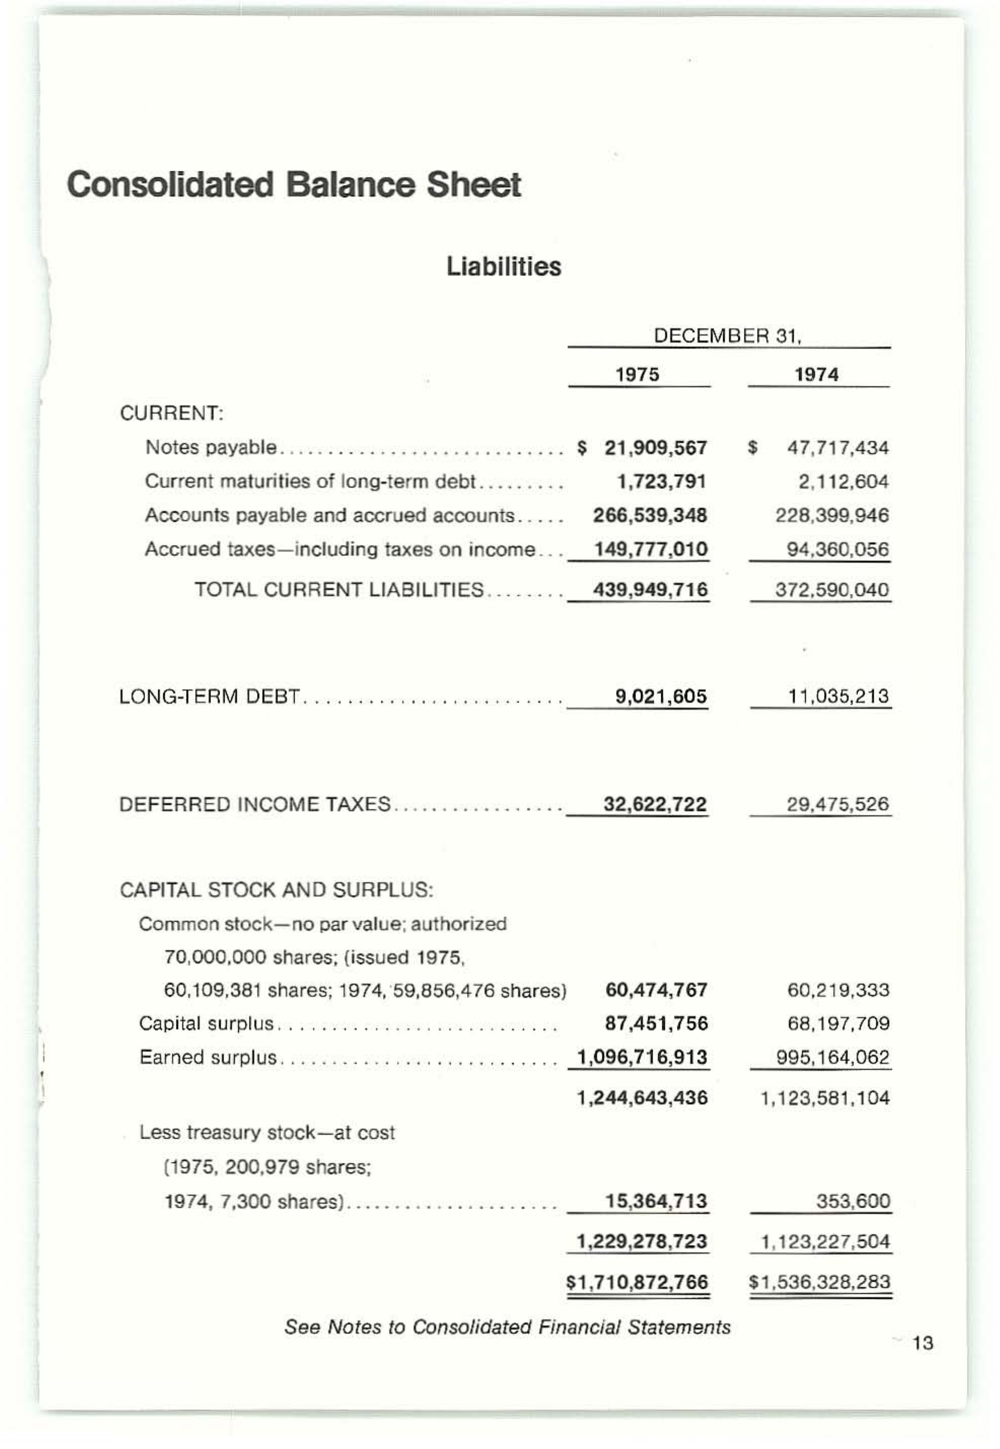

In [17]:
from PIL import Image
img = Image.open('/content/drive/MyDrive/annual-report-ocr/output/page15_raw.png')
img.thumbnail((1000, 1500))  # Resize for display
img

In [18]:
ground_truth_numbers = [
    # CURRENT LIABILITIES (1975, 1974)
    "21909567",    "47717434",     # Notes payable
    "1723791",     "2112604",      # Current maturities of long-term debt
    "266539348",   "228399946",    # Accounts payable and accrued accounts
    "149777010",   "94360056",     # Accrued taxes
    "439949716",   "372590040",    # TOTAL CURRENT LIABILITIES

    # LONG-TERM DEBT
    "9021605",     "11035213",

    # DEFERRED INCOME TAXES
    "32622722",    "29475526",

    # CAPITAL STOCK AND SURPLUS
    "70000000",                    # authorized shares (only one column)
    "60109381",                    # 1975 issued shares
    "59856476",                    # 1974 issued shares
    "60474767",    "60219333",     # Common stock
    "87451756",    "68197709",     # Capital surplus
    "1096716913",  "995164062",    # Earned surplus
    "1244643436",  "1123581104",   # subtotal

    # Treasury stock
    "200979",                      # 1975 treasury shares
    "7300",                        # 1974 treasury shares
    "15364713",    "353600",       # treasury stock at cost
    "1229278723",  "1123227504",   # subtotal after treasury

    # GRAND TOTAL
    "1710872766",  "1536328283",
]

with open('/content/drive/MyDrive/annual-report-ocr/output/page15_ground_truth.txt', 'w') as f:
    f.write('\n'.join(ground_truth_numbers))

print(f"Ground truth: {len(ground_truth_numbers)} numbers")

Ground truth: 33 numbers


In [19]:
import re

def normalize_number(n):
    return re.sub(r'[,\.\s]', '', n)

def extract_dollar_amounts(text):
    pattern = r'\b\d{1,3}(?:,\d{3})+\b|\b\d{4,}\b'
    return [normalize_number(n) for n in re.findall(pattern, text)]

with open('/content/drive/MyDrive/annual-report-ocr/output/page15_ground_truth.txt') as f:
    truth = set(line.strip() for line in f if line.strip())

with open('/content/drive/MyDrive/annual-report-ocr/output/page15_ocr_baseline.txt') as f:
    ocr_output = f.read()

ocr_amounts = set(extract_dollar_amounts(ocr_output))

matched = truth & ocr_amounts
missed = truth - ocr_amounts
extra = ocr_amounts - truth

precision = len(matched) / len(ocr_amounts) * 100 if ocr_amounts else 0
recall = len(matched) / len(truth) * 100 if truth else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0

print(f"Ground truth numbers: {len(truth)}")
print(f"OCR numbers:          {len(ocr_amounts)}")
print(f"Matched exactly:      {len(matched)}")
print()
print(f"Precision: {precision:.1f}%")
print(f"Recall:    {recall:.1f}%")
print(f"F1 score:  {f1:.1f}%  ← THIS IS YOUR REAL BASELINE")
print()
print(f"Missed:  {sorted(missed)}")
print(f"Extras:  {sorted(extra)}")

Ground truth numbers: 33
OCR numbers:          33
Matched exactly:      31

Precision: 93.9%
Recall:    93.9%
F1 score:  93.9%  ← THIS IS YOUR REAL BASELINE

Missed:  ['1536328283', '1710872766']
Extras:  ['1974', '1975']


In [20]:
import cv2
import numpy as np
from PIL import Image
import pytesseract
import re

def preprocess_image(image_path):
    """Apply OpenCV preprocessing to improve OCR on financial documents."""
    # Load as grayscale
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    # 1. Otsu's thresholding — converts to pure black/white based on optimal threshold
    _, binary = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # 2. Remove horizontal lines (the underlines that confuse Tesseract)
    # Detect long horizontal lines using morphological operations
    horizontal_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (40, 1))
    detected_lines = cv2.morphologyEx(
        cv2.bitwise_not(binary), cv2.MORPH_OPEN, horizontal_kernel, iterations=2
    )

    # Subtract the lines from the binary image
    cleaned = cv2.bitwise_or(binary, detected_lines)

    return cleaned

# Run preprocessing
processed = preprocess_image('/content/drive/MyDrive/annual-report-ocr/output/page15_raw.png')

# Save for inspection
cv2.imwrite('/content/drive/MyDrive/annual-report-ocr/output/page15_processed.png', processed)

# OCR the processed image
ocr_text_v2 = pytesseract.image_to_string(processed)

with open('/content/drive/MyDrive/annual-report-ocr/output/page15_ocr_v2.txt', 'w') as f:
    f.write(ocr_text_v2)

print(f"OCR v2 extracted: {len(ocr_text_v2)} characters")
print("--- First 600 chars ---")
print(ocr_text_v2[:600])

OCR v2 extracted: 1082 characters
--- First 600 chars ---
Consolidated Balance Sheet

DECEMBER 31,

Liabilities
1975
CURRENT:
Notes payable...........000..00.0..0.0... $ 21,909,567
Current maturities of long-term debt......... 1,723,791
Accounts payable and accrued accounts..... 266,539,348
Accrued taxes—including taxes on income... 149,777,010
TOTAL CURRENT LIABILITIES........ _ 439,949,716
LONG-TERM DEBT............ 0.0.00 .02 00s 9,021,605
DEFERRED INCOME TAXES................. ___ 32,622,722
CAPITAL STOCK AND SURPLUS:

Common stock—no par value; authorized
70,000,000 shares; (issued 1975,
60,109,381 shares; 1974, 59,856,476 shares) 60,474,767

Ca


In [21]:
def extract_dollar_amounts(text):
    pattern = r'\b\d{1,3}(?:,\d{3})+\b|\b\d{4,}\b'
    return [re.sub(r'[,\.\s]', '', n) for n in re.findall(pattern, text)]

with open('/content/drive/MyDrive/annual-report-ocr/output/page15_ground_truth.txt') as f:
    truth = set(line.strip() for line in f if line.strip())

ocr_amounts_v2 = set(extract_dollar_amounts(ocr_text_v2))

matched = truth & ocr_amounts_v2
missed = truth - ocr_amounts_v2
extra = ocr_amounts_v2 - truth

precision = len(matched) / len(ocr_amounts_v2) * 100 if ocr_amounts_v2 else 0
recall = len(matched) / len(truth) * 100 if truth else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0

print(f"=== BASELINE: 93.9% F1 ===")
print(f"=== AFTER LINE REMOVAL ===")
print(f"Precision: {precision:.1f}%")
print(f"Recall:    {recall:.1f}%")
print(f"F1 score:  {f1:.1f}%")
print()
print(f"Missed:  {sorted(missed)}")
print(f"Extras:  {sorted(extra)}")

=== BASELINE: 93.9% F1 ===
=== AFTER LINE REMOVAL ===
Precision: 85.7%
Recall:    90.9%
F1 score:  88.2%

Missed:  ['1123227504', '200979', '2112604']
Extras:  ['00005', '112604', '123227504', '1974', '1975']
